# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
3. True or false, and explain: Logistic regression is a linear model.
4. True or false, and explain: Logistic regression cannot be used for classification.
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

### Answers
1 These modles allow us to map linear combinations of features to outpits that are bounded or follow specific distributions. Notably, logistic regression only maps real probabilities (between 0 and 1), whereas linear models dont necessarily have to and can predict impossible values (negative probabilities)
2 Cross entropy measures how far predicted probabilities are from the true class labels, so it penalizes confident wrong predictions and rewards confident correct ones. This proves it is strong for classification
3 True, logistic regression is linear and applies a linear combination of features and passes it through a sigmoid function.
4 False, logistic regression is commonly used for classification for thresholding predicted probabilities
5 No, in logistic regression, a one unit increase in a feature changes the log-odds of the outcome by the coeffiicient value. It does not directly change the predicted probability. 
6 False, logistic regression is actually a linear model, so feature engineering is still important. Without feature engineering, the model cannot capture nonlinear relationships between features and the outcome
7 False, logistic regression is more appropriate for classification tasks whereas for continous outcome prediction, linear regression is more suitable. They both have their strengths, but no model is universally better than the other. Model choice depends on the outcome variable

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score


# 1
df_q1 = pd.read_csv('data/data.csv', sep=';')
print(df_q1.isnull().sum())


Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance\t                      0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

For this particular dataset, there are no missing values, so there was no extra cleaning required to handle missing values.

In [14]:
cols = ['Debtor', 'Tuition fees up to date', 'Scholarship holder', 
        'Age at enrollment', 'Curricular units 1st sem (approved)', 'Target']
df_q1 = df_q1[cols]
df_q1.head()

,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment,Curricular units 1st sem (approved),Target
0,0,1,0,20,0,Dropout
1,0,0,0,19,6,Graduate
2,0,0,0,19,0,Dropout
3,0,1,0,20,6,Graduate
4,0,1,0,45,5,Graduate


In [15]:
df_q1['target_binary'] = (df_q1['Target'] == 'Dropout').astype(int)
df_q1.head()

,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment,Curricular units 1st sem (approved),Target,target_binary
0,0,1,0,20,0,Dropout,1
1,0,0,0,19,6,Graduate,0
2,0,0,0,19,0,Dropout,1
3,0,1,0,20,6,Graduate,0
4,0,1,0,45,5,Graduate,0


In [16]:
#2
features = ['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment']
X = df_q1[features]
y = df_q1['target_binary']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LogisticRegression(random_state=42)
model.fit(X_scaled, y)

coef_df = pd.DataFrame({
    'Variable': features,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', ascending=False)

print("Logistic Regression Coefficients:")
print(coef_df.to_string(index=False))

Logistic Regression Coefficients:
               Variable  Coefficient
      Age at enrollment     0.377733
                 Debtor     0.167333
     Scholarship holder    -0.535580
Tuition fees up to date    -0.843055


Age at enrollment and Debtor both ahve positive coefficients, meaning older students and studentswithout outstanding debt are more likely to drop out. Tution fees up to date has teh strongest effect,meaning students who are up to date on their tution are much less likely to drop out. Similarly for being a scholarship holder, this also reduces drop out rate significantly.

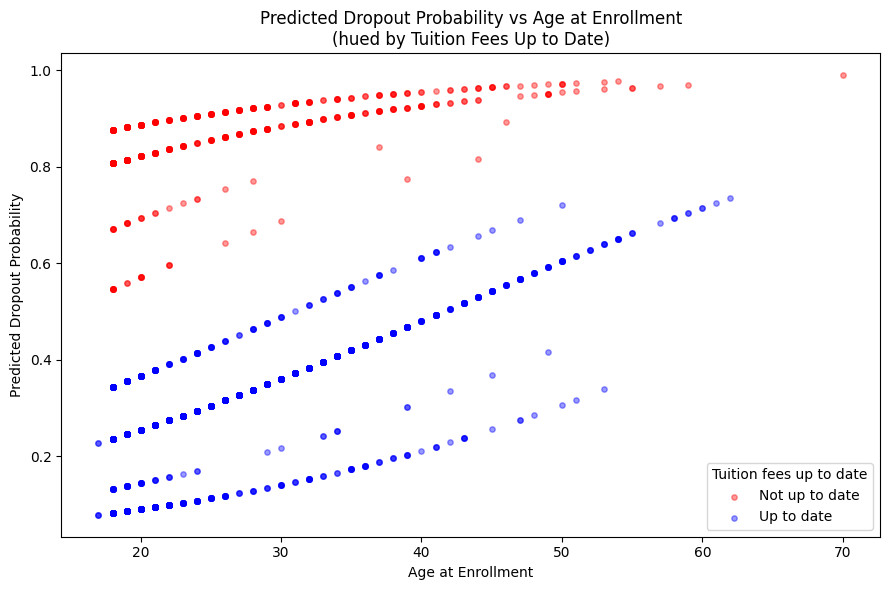

In [17]:
#3
df_q1['dropout_prob'] = model.predict_proba(X_scaled)[:, 1]

fig, ax = plt.subplots(figsize=(9, 6))

for tuition_status, group in df_q1.groupby('Tuition fees up to date'):
    label = 'Up to date' if tuition_status == 1 else 'Not up to date'
    color = 'blue' if tuition_status == 1 else 'red'
    ax.scatter(group['Age at enrollment'], group['dropout_prob'],
               label=label, alpha=0.4, s=15, color=color)

ax.set_xlabel('Age at Enrollment')
ax.set_ylabel('Predicted Dropout Probability')
ax.set_title('Predicted Dropout Probability vs Age at Enrollment\n(hued by Tuition Fees Up to Date)')
ax.legend(title='Tuition fees up to date')
plt.tight_layout()
plt.show()

Being up to date on tuition reduces dropout probability the most for younger studnets as depicted by the graph

In [18]:
avg_not_uptodate = df_q1[df_q1['Tuition fees up to date'] == 0]['dropout_prob'].mean()
avg_uptodate     = df_q1[df_q1['Tuition fees up to date'] == 1]['dropout_prob'].mean()

print(f"Avg dropout prob (NOT up to date): {avg_not_uptodate:.4f}")
print(f"Avg dropout prob (up to date):     {avg_uptodate:.4f}")
print(f"Average reduction:                 {avg_not_uptodate - avg_uptodate:.4f}")

Avg dropout prob (NOT up to date): 0.8650
Avg dropout prob (up to date):     0.2475
Average reduction:                 0.6175


On average, being up to date on tuition reduces the predicted dropout probability by apporximately 61.75 percentage points. This is strongest for the younger students as noted between the gap in red (not up to date with tution) and blue (up to date with tuition).

In [19]:
#4
y_pred = model.predict(X_scaled)

print(pd.crosstab(y, y_pred, rownames=['Actual'], colnames=['Predicted']))

accuracy = accuracy_score(y, y_pred)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

Predicted     0    1
Actual              
0          2841  162
1           891  530
Accuracy: 0.7620 (76.20%)


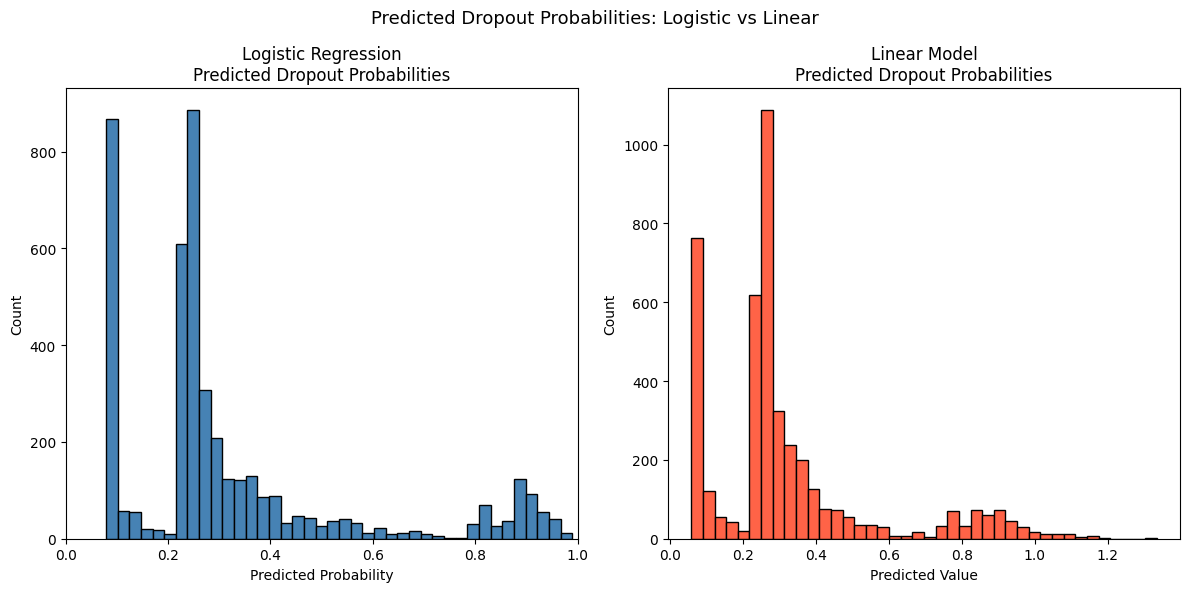

In [20]:
#5
linear_model = LinearRegression()
linear_model.fit(X_scaled, y)

df_q1['dropout_prob_linear'] = linear_model.predict(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].hist(df_q1['dropout_prob'], bins=40, color='steelblue', edgecolor='black')
axes[0].set_title('Logistic Regression\nPredicted Dropout Probabilities')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Count')
axes[0].set_xlim(0, 1)

axes[1].hist(df_q1['dropout_prob_linear'], bins=40, color='tomato', edgecolor='black')
axes[1].set_title('Linear Model\nPredicted Dropout Probabilities')
axes[1].set_xlabel('Predicted Value')
axes[1].set_ylabel('Count')

plt.suptitle('Predicted Dropout Probabilities: Logistic vs Linear', fontsize=13)
plt.tight_layout()
plt.show()

In [21]:
y_pred_linear = (df_q1['dropout_prob_linear'] >= 0.5).astype(int)
linear_acc = accuracy_score(y, y_pred_linear)
logistic_acc = accuracy_score(y, y_pred)

print(f"Logistic Regression Accuracy: {logistic_acc:.4f}")
print(f"Linear Model Accuracy:        {linear_acc:.4f}")

out_of_range = ((df_q1['dropout_prob_linear'] < 0) | 
                (df_q1['dropout_prob_linear'] > 1)).sum()
print(f"Linear predictions outside [0,1]: {out_of_range}")

Logistic Regression Accuracy: 0.7620
Linear Model Accuracy:        0.7633
Linear predictions outside [0,1]: 57


The last "out of range" variable code was assisted by AI and shows that 57 predictions from the linear model are outside the [0,1] range, meaning it cannot be trusted as a true probability estimator, therefore Logistic regression is the better choice with almost identical accuracy.

### 6
Based on the model, students most at risk of dropping out are those who are not up to date on tuition, have outstanding debt, do not hold a scholarship, and are older at enrollment. Some interventions may include extra financial aid or payment plans for students who are behind on tuition, more scholarship opportunities, or targetted outreach for older students who may have other obligations such as work, family life, or other obligations.

In [22]:
#7
actual_labels = y.map({0: 'Not Dropout', 1: 'Dropout'})
pred_labels = pd.Series(y_pred).map({0: 'Not Dropout', 1: 'Dropout'})

print(pd.crosstab(actual_labels, pred_labels, rownames=['Actual'], colnames=['Predicted']))

accuracy = accuracy_score(y, y_pred)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

Predicted    Dropout  Not Dropout
Actual                           
Dropout          530          891
Not Dropout      162         2841
Accuracy: 0.7620 (76.20%)


In [24]:
features_q7 = ['Debtor', 'Tuition fees up to date', 'Curricular units 1st sem (approved)']
X_q7 = df_q1[features_q7]
y_q7 = df_q1['Target']  

scaler_q7 = StandardScaler()
X_q7_scaled = scaler_q7.fit_transform(X_q7)

multi_model = LogisticRegression(max_iter=1000, random_state=42)
multi_model.fit(X_q7_scaled, y_q7)

# Hard classification + crosstab
y_q7_pred = multi_model.predict(X_q7_scaled)
acc_q7 = accuracy_score(y_q7, y_q7_pred)
prob_df = pd.DataFrame(multi_model.predict_proba(X_q7_scaled),
                       columns=multi_model.classes_)
print(prob_df.head(10).round(4))
print(f"\nClasses predicted by hard classifier: {set(y_q7_pred)}")
print(f"Classes with nonzero predicted probability: {prob_df.columns[(prob_df > 0).any()].tolist()}")

   Dropout  Enrolled  Graduate
0   0.6795    0.2109    0.1096
1   0.7050    0.1454    0.1496
2   0.9539    0.0406    0.0054
3   0.1176    0.1768    0.7056
4   0.1838    0.2125    0.6037
5   0.3071    0.3251    0.3678
6   0.0718    0.1406    0.7876
7   0.9539    0.0406    0.0054
8   0.1176    0.1768    0.7056
9   0.8421    0.1223    0.0357

Classes predicted by hard classifier: {'Graduate', 'Dropout'}
Classes with nonzero predicted probability: ['Dropout', 'Enrolled', 'Graduate']


The hard classifier only predicts two out of the three clases (Graduate and Dropout) and never predicts Enrolled. However, the predicted probabilities do assign each class a nonzero value as can be seen. While the hard classifier fails to predict every class, the predicted probabilities do repreent all three classes. 

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics 
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class? 

In [ ]:
#1
df_q3 = pd.read_csv('data/cirrhosis.csv')
cols_q3 = ['Bilirubin', 'Edema', 'Drug', 'Stage', 'Status']
df_q3 = df_q3[cols_q3]

df_q3.head()

,Bilirubin,Edema,Drug,Stage,Status
0,14.5,Y,D-penicillamine,4.0,D
1,1.1,N,D-penicillamine,3.0,C
2,1.4,S,D-penicillamine,4.0,D
3,1.8,S,D-penicillamine,4.0,D
4,3.4,N,Placebo,3.0,CL


In [ ]:
print("Missing values per column:")
print(df_q3.isnull().sum())


Missing values per column:
Bilirubin      0
Edema          0
Drug         106
Stage          6
Status         0
dtype: int64


In [ ]:
df_q3 = df_q3.dropna()

For the sake of this problem, I dropped all missing values (since it is medical data, I felt it was best practice)

In [ ]:
#2
df_q3['Drug_binary'] = (df_q3['Drug'] == 'D-penicillamine').astype(int)
df_q3['Edema_encoded'] = df_q3['Edema'].map({'N': 0, 'S': 1, 'Y': 2})
df_q3['target_survival'] = (df_q3['Status'] != 'D').astype(int)

features_q3 = ['Edema_encoded', 'Drug_binary', 'Bilirubin']
X_q3 = df_q3[features_q3]
y_q3 = df_q3['target_survival']

scaler_q3 = StandardScaler()
X_q3_scaled = scaler_q3.fit_transform(X_q3)

model_q3 = LogisticRegression(random_state=42)
model_q3.fit(X_q3_scaled, y_q3)

for feature, coef in zip(features_q3, model_q3.coef_[0]):
    print(f"{feature}: {coef:.4f}")

Edema_encoded: -0.5360
Drug_binary: -0.1147
Bilirubin: -1.4642


All three variables have negative coefficients, meaning they all reduce survival probability. Higher bilirubin predicts lower survival rate and more severe edema reduces survival probability.

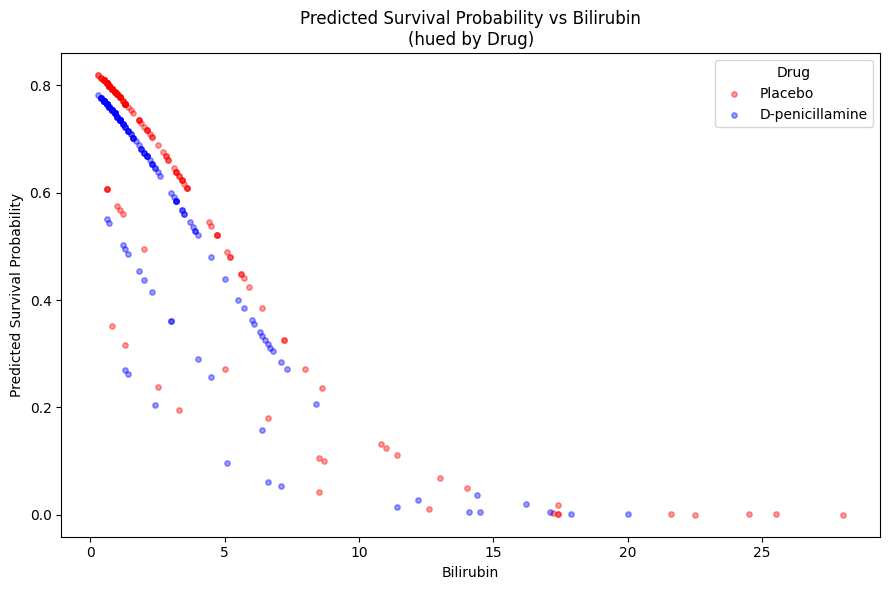

In [ ]:
#3
df_q3['survival_prob'] = model_q3.predict_proba(X_q3_scaled)[:, 1]

fig, ax = plt.subplots(figsize=(9, 6))

for drug_status, group in df_q3.groupby('Drug_binary'):
    label = 'D-penicillamine' if drug_status == 1 else 'Placebo'
    color = 'blue' if drug_status == 1 else 'red'
    ax.scatter(group['Bilirubin'], group['survival_prob'],
               label=label, alpha=0.4, s=15, color=color)

ax.set_xlabel('Bilirubin')
ax.set_ylabel('Predicted Survival Probability')
ax.set_title('Predicted Survival Probability vs Bilirubin\n(hued by Drug)')
ax.legend(title='Drug')
plt.tight_layout()
plt.show()

In [ ]:
avg_placebo = df_q3[df_q3['Drug_binary'] == 0]['survival_prob'].mean()
avg_drug    = df_q3[df_q3['Drug_binary'] == 1]['survival_prob'].mean()

print(f"Avg survival prob (Placebo):         {avg_placebo:.4f}")
print(f"Avg survival prob (D-penicillamine): {avg_drug:.4f}")
print(f"Average difference:                  {avg_drug - avg_placebo:.4f}")

Avg survival prob (Placebo):         0.6100
Avg survival prob (D-penicillamine): 0.5890
Average difference:                  -0.0210


As Biliribuin increases, predicted survival probability decreases sharply for both groups. The placebo group dots sit higher than the D-penicillamine group across the Bilirubin values. This shows that the drug does not appear to increase patient survival rate at any value of Bilirubin.

In [ ]:
#4
y_q3_pred = model_q3.predict(X_q3_scaled)

actual_labels_q3 = y_q3.map({0: 'Dead', 1: 'Alive'})
pred_labels_q3 = pd.Series(y_q3_pred).map({0: 'Dead', 1: 'Alive'})

print(pd.crosstab(actual_labels_q3, pred_labels_q3, rownames=['Actual'], colnames=['Predicted']))

acc_q3 = accuracy_score(y_q3, y_q3_pred)
print(f"Accuracy: {acc_q3:.4f} ({acc_q3*100:.2f}%)")

Predicted  Alive  Dead
Actual                
Alive        172    15
Dead          63    62
Accuracy: 0.7500 (75.00%)


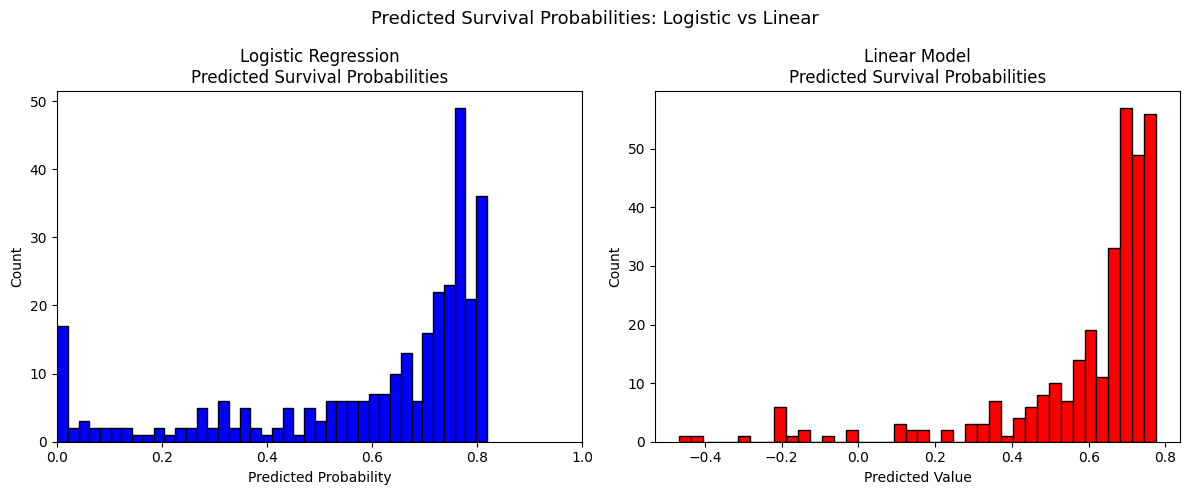

In [ ]:
#5
linear_model_q3 = LinearRegression()
linear_model_q3.fit(X_q3_scaled, y_q3)

df_q3['survival_prob_linear'] = linear_model_q3.predict(X_q3_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df_q3['survival_prob'], bins=40, color='blue', edgecolor='black')
axes[0].set_title('Logistic Regression\nPredicted Survival Probabilities')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Count')
axes[0].set_xlim(0, 1)

axes[1].hist(df_q3['survival_prob_linear'], bins=40, color='red', edgecolor='black')
axes[1].set_title('Linear Model\nPredicted Survival Probabilities')
axes[1].set_xlabel('Predicted Value')
axes[1].set_ylabel('Count')

plt.suptitle('Predicted Survival Probabilities: Logistic vs Linear', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
y_q3_pred_linear = (df_q3['survival_prob_linear'] >= 0.5).astype(int)
linear_acc_q3 = accuracy_score(y_q3, y_q3_pred_linear)

print(f"Logistic Regression Accuracy: {acc_q3:.4f}")
print(f"Linear Model Accuracy:        {linear_acc_q3:.4f}")

out_of_range_q3 = ((df_q3['survival_prob_linear'] < 0) | 
                   (df_q3['survival_prob_linear'] > 1)).sum()
print(f"Linear predictions outside [0,1]: {out_of_range_q3}")

Logistic Regression Accuracy: 0.7500
Linear Model Accuracy:        0.7276
Linear predictions outside [0,1]: 15


Logistic regression slightly outperforms the linear model by ~2.24%. In logistic regression (like before), there were no predictions outside of [0,1], but in the linear model, there were 15 predictions outside of that range as can be seen with the negative predictions. Logistic regression is a more appropriate model for this prediction as it includes a binary classification and will always produce valid probabilities.

In [ ]:
#6
features_q3_p6 = ['Edema_encoded', 'Bilirubin']
X_q3_p6 = df_q3[features_q3_p6]
y_q3_p6 = df_q3['Stage']

scaler_q3_p6 = StandardScaler()
X_q3_p6_scaled = scaler_q3_p6.fit_transform(X_q3_p6)

multi_model_q3 = LogisticRegression(max_iter=1000, random_state=42)
multi_model_q3.fit(X_q3_p6_scaled, y_q3_p6)

y_q3_p6_pred = multi_model_q3.predict(X_q3_p6_scaled)
acc_q3_p6 = accuracy_score(y_q3_p6, y_q3_p6_pred)

print(pd.crosstab(y_q3_p6, y_q3_p6_pred, rownames=['Actual'], colnames=['Predicted']))
print(f"Accuracy: {acc_q3_p6:.4f} ({acc_q3_p6*100:.2f}%)")

Predicted  3.0  4.0
Actual             
1.0         16    0
2.0         61    6
3.0        102   18
4.0         74   35
Accuracy: 0.4391 (43.91%)


In [ ]:
prob_df_q3_p6 = pd.DataFrame(multi_model_q3.predict_proba(X_q3_p6_scaled),
                              columns=multi_model_q3.classes_)
print("Sample predicted probabilities:")
print(prob_df_q3_p6.head(10).round(4))

Sample predicted probabilities:
      1.0     2.0     3.0     4.0
0  0.0000  0.0255  0.1621  0.8123
1  0.0723  0.2531  0.4017  0.2729
2  0.0152  0.1697  0.3411  0.4740
3  0.0134  0.1646  0.3404  0.4816
4  0.0372  0.2251  0.4211  0.3166
5  0.0787  0.2563  0.3982  0.2669
6  0.0744  0.2541  0.4006  0.2709
7  0.0904  0.2612  0.3917  0.2568
8  0.0395  0.2277  0.4199  0.3130
9  0.0001  0.0312  0.1728  0.7960


The hard classifier achieves a 43.91% accuracy and only predicts two of the four stages. It does not predict stage one or stage two, only stages three and four. This suggests that the model struggles to predict early stages using Edema and Bilirubin. The predicted probabilities do assign nonzero probabilities to all four stages, just with stages one and two never being the highest. 

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio? 

## Answers
### 1
For a linear model, the derivative of the prediction with respect to the $k$-th feature is:

$$\frac{\partial \hat{y}}{\partial x_k} = b_k$$

For a 1-unit change in feature $x_k$, the prediction changes by exactly $b_k$.

### 2

Using the chain rule $D_z f(g(x)) = f'(g(x))g'(x)$, where:
- $g(x) = L = b \cdot x$, so $\frac{\partial L}{\partial x_k} = b_k$
- From the hint: $\frac{\partial}{\partial L}\frac{e^L}{1+e^L} = \frac{e^L}{1+e^L}\left(1 - \frac{e^L}{1+e^L}\right) = \hat{p}(1-\hat{p})$

The derivative of the prediction with respect to $x_k$ is:

$$\frac{\partial \hat{p}}{\partial x_k} = b_k \cdot \hat{p}(1 - \hat{p})$$

Yes, the answer changes as $x$ changes. 

In part 1 (linear regression), the derivative $\frac{\partial \hat{y}}{\partial x_k} = b_k$ 
is constant — it does not depend on the value of $x$ at all.

In part 2 (logistic regression), the derivative $\frac{\partial \hat{p}}{\partial x_k} = b_k \cdot \hat{p}(1-\hat{p})$ 
changes as $x$ changes, because $\hat{p}$ itself depends on $x$. 
As $x$ shifts, $\hat{p}$ shifts, and so does the multiplier $\hat{p}(1-\hat{p})$.

Both answers share the factor $b_k$, but logistic regression adds a 
non-constant scaling term $\hat{p}(1-\hat{p})$ that makes the effect 
of $x_k$ on the prediction vary across the range of $x$.

The coefficient $b_k$ (times 4) is a good estimate when $\hat{p} \approx 0.5$, 
because at that value:

$$\hat{p}(1-\hat{p}) = 0.5 \times 0.5 = 0.25 = \frac{1}{4}$$

So the derivative simplifies to $\frac{b_k}{4}$, meaning $b_k$ is 
approximately 4 times the change in prediction per unit $x_k$.

As $\hat{p}$ moves away from 0.5 (toward 0 or 1), 
$\hat{p}(1-\hat{p})$ shrinks toward 0, and the approximation 
becomes increasingly poor.


### 3

A one unit change in $x_k$ increases the log odds ratio by exactly $b_k$.

This is a constant effect, regardless of the value of $x_k$ or $\hat{p}$ — 
making it directly interpretable, just like the coefficient in linear regression.